# EDA: BreastDCEDL, predicción de pCR

Análisis exploratorio antes de fijar el modelo. Cada sección responde a una pregunta
cuya respuesta cambia alguna decisión de diseño:

1. **Clases**: cuánto desbalance hay y a qué nivel (paciente o corte).
2. **Cohortes**: si spy1, spy2 y duke se diferencian en la etiqueta y en la adquisición.
3. **Variables clínicas**: cuánto predice el subtipo tumoral por sí solo.
4. **Imágenes**: cómo se ven las fases y el realce en casos pCR=0 y pCR=1.
5. **Intensidades por cohorte**: si la red podría reconocer la cohorte en vez del tumor.
6. **Realce y pCR**: si la cinética del contraste separa las clases.
7. **Cortes de una paciente**: cuánto se parecen entre sí y si son contiguos.

**Regla**: todo se calcula solo sobre `train`. `test` no se mira (ni imágenes ni
etiquetas) hasta la evaluación final. Las figuras se guardan en `docs/figuras/`.

In [1]:
import sys
from pathlib import Path

# El cuaderno vive en notebooks/: la raiz del repo (donde esta src/) va al path
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists())
sys.path.insert(0, str(REPO))

# torch ANTES que matplotlib: al reves, en Windows chocan sus DLL y el kernel muere
# al dibujar. El EDA no usa torch, pero utils_caso lo importa por dentro.
import torch  # noqa: F401
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src import config

uc = config.utils()
FIGURAS = config.FIGURAS
FIGURAS.mkdir(parents=True, exist_ok=True)
COHORTES = ["spy1", "spy2", "duke"]
COLOR = {"spy1": "#4C72B0", "spy2": "#DD8452", "duke": "#55A868"}
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})


def guardar(figura, nombre):
    figura.savefig(FIGURAS / f"eda_{nombre}.png", dpi=150, bbox_inches="tight", facecolor="white")


samples = uc.cargar_samples()
patients = uc.cargar_patients()

# Solo entrenamiento: test no se mira hasta la evaluacion final
train = samples[samples.split == "train"].copy()
pac = patients[patients.split == "train"].set_index("pid")
pac["fold"] = train.groupby("patient_id").fold.first()
train["cohorte"] = train.patient_id.map(pac.dataset)
print(f"{len(pac)} pacientes y {len(train)} cortes de entrenamiento")

1097 pacientes y 10945 cortes de entrenamiento


## 1. Clases

pCR es una propiedad de la paciente, así que el desbalance que importa es el de
pacientes. Si el porcentaje por corte fuese distinto, alguna clase aportaría más
cortes por paciente y el modelo la vería más.

In [2]:
resumen = pd.DataFrame({
    "pacientes": pac.pCR.value_counts().sort_index(),
    "cortes": train.pCR.value_counts().sort_index(),
})
resumen.index = ["pCR=0 (enfermedad residual)", "pCR=1 (respuesta completa)"]
resumen["% pacientes"] = (100 * resumen.pacientes / resumen.pacientes.sum()).round(1)
resumen["% cortes"] = (100 * resumen.cortes / resumen.cortes.sum()).round(1)
display(resumen)

cortes_por_paciente = train.groupby("patient_id").size()
print("Cortes por paciente:", cortes_por_paciente.value_counts().sort_index().to_dict())
print(f"pos_weight (N0/N1 en cortes): {uc.pos_weight(train):.3f}")
print(f"Accuracy de predecir siempre pCR=0: {1 - pac.pCR.mean():.1%}")

,pacientes,cortes,% pacientes,% cortes
pCR=0 (enfermedad residual),775,7729,70.6,70.6
pCR=1 (respuesta completa),322,3216,29.4,29.4


Cortes por paciente: {5: 2, 6: 3, 7: 1, 10: 1091}
pos_weight (N0/N1 en cortes): 2.403
Accuracy de predecir siempre pCR=0: 70.6%


## 2. Cohortes

Las tres cohortes vienen de ensayos y hospitales distintos. Si además tienen tasas
de pCR distintas, la cohorte es un **atajo**: una red que sepa reconocer el
hospital ya acierta algo sin mirar el tumor.

In [3]:
tabla = (pac.groupby("dataset")
            .agg(pacientes=("pCR", "size"), pCR_1=("pCR", "sum"), tasa_pCR=("pCR", "mean"))
            .loc[COHORTES])
tabla["tasa_pCR"] = (100 * tabla.tasa_pCR).round(1)
display(tabla)

chi2, p, _, _ = chi2_contingency(pd.crosstab(pac.dataset, pac.pCR))
print(f"Chi-cuadrado cohorte x pCR: p = {p:.2g}")

adquisicion = ["n_xy", "n_z", "n_times", "post_early", "post_late", "slice_thick", "xy_spacing", "tum_vol"]
print("\nMedianas de adquisicion por cohorte:")
display(pac.groupby("dataset")[adquisicion].median().loc[COHORTES].round(2))

,pacientes,pCR_1,tasa_pCR
dataset,,,
spy1,104,26,25.0
spy2,784,252,32.1
duke,209,44,21.1


Chi-cuadrado cohorte x pCR: p = 0.0044

Medianas de adquisicion por cohorte:


,n_xy,n_z,n_times,post_early,post_late,slice_thick,xy_spacing,tum_vol
dataset,,,,,,,,
spy1,256.0,60.0,3.0,1.0,2.0,2.3,0.78,14.45
spy2,256.0,80.0,7.0,2.0,5.0,2.0,0.68,14.71
duke,256.0,31.0,4.0,1.0,3.0,2.0,0.70,6.14


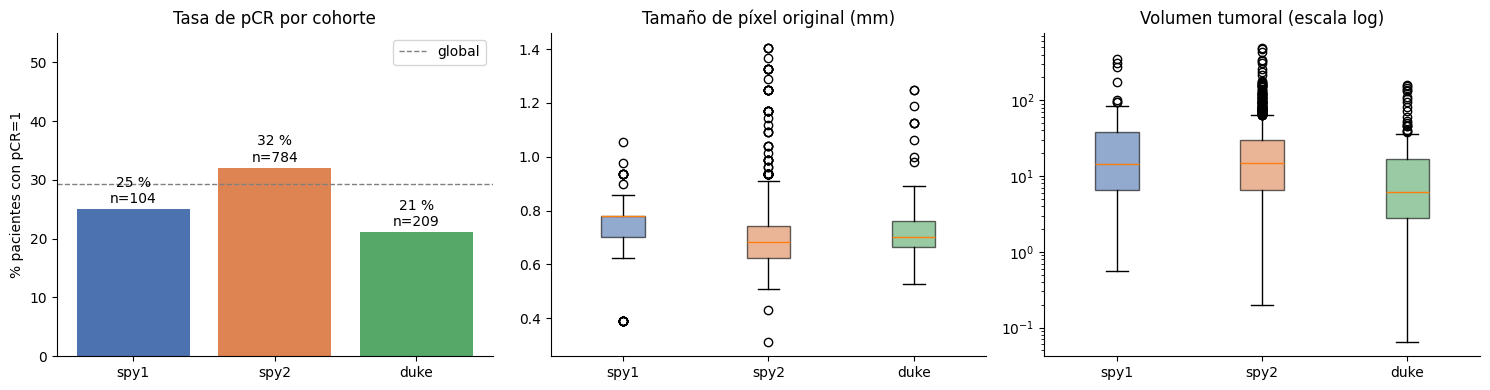

In [4]:
figura, ejes = plt.subplots(1, 3, figsize=(15, 4))

ejes[0].bar(COHORTES, tabla.tasa_pCR, color=[COLOR[c] for c in COHORTES])
ejes[0].axhline(100 * pac.pCR.mean(), color="gray", ls="--", lw=1, label="global")
for i, c in enumerate(COHORTES):
    ejes[0].text(i, tabla.tasa_pCR[c] + 1, f"{tabla.tasa_pCR[c]:.0f} %\nn={tabla.pacientes[c]}", ha="center")
ejes[0].set(title="Tasa de pCR por cohorte", ylabel="% pacientes con pCR=1", ylim=(0, 55))
ejes[0].legend()

for eje, columna, titulo in [(ejes[1], "xy_spacing", "Tamaño de píxel original (mm)"),
                             (ejes[2], "tum_vol", "Volumen tumoral (escala log)")]:
    datos = [pac.loc[pac.dataset == c, columna].dropna() for c in COHORTES]
    caja = eje.boxplot(datos, tick_labels=COHORTES, patch_artist=True)
    for parche, c in zip(caja["boxes"], COHORTES):
        parche.set_facecolor(COLOR[c])
        parche.set_alpha(0.6)
    eje.set_title(titulo)
ejes[2].set_yscale("log")
figura.tight_layout()
guardar(figura, "cohortes")

## 3. Variables clínicas

El subtipo tumoral (receptores hormonales HR y HER2) es un predictor conocido de pCR.
Aquí se mide cuánto predice sin imagen, con una regresión logística validada con los
mismos 5 folds por paciente que usará la CNN. Sirve de **referencia**: una CNN que no
supere a esto no aporta nada sobre el subtipo, y es la base para la pregunta al
profesor de si se pueden usar estas variables.

In [5]:
subtipos = pac.groupby("HR_HER2_STATUS").pCR.agg(pacientes="size", tasa_pCR="mean")
subtipos["tasa_pCR"] = (100 * subtipos.tasa_pCR).round(1)
display(subtipos.sort_values("tasa_pCR"))

print("Composicion de cada cohorte por subtipo (% de sus pacientes):")
display((100 * pd.crosstab(pac.HR_HER2_STATUS, pac.dataset, normalize="columns"))[COHORTES].round(1))

for columna in ["age", "tum_vol"]:
    a, b = pac.loc[pac.pCR == 0, columna].dropna(), pac.loc[pac.pCR == 1, columna].dropna()
    print(f"{columna}: mediana pCR=0 {a.median():.1f} | pCR=1 {b.median():.1f} | "
          f"Mann-Whitney p = {mannwhitneyu(a, b).pvalue:.2g}")

,pacientes,tasa_pCR
HR_HER2_STATUS,,
HRposHER2neg,453,14.1
TripleNeg,354,37.9
HER2pos,287,42.9


Composicion de cada cohorte por subtipo (% de sus pacientes):


dataset,spy1,spy2,duke
HR_HER2_STATUS,,,
HER2pos,31.7,25.3,27.3
HRposHER2neg,41.6,38.9,50.7
TripleNeg,26.7,35.8,22.0


age: mediana pCR=0 49.0 | pCR=1 48.0 | Mann-Whitney p = 0.029
tum_vol: mediana pCR=0 13.4 | pCR=1 10.5 | Mann-Whitney p = 0.017


In [6]:
def auc_por_folds(datos, numericas, categoricas):
    # AUC de una regresion logistica con validacion cruzada por los folds de paciente
    aucs = []
    for k in range(5):
        entreno, valida = datos[datos.fold != k], datos[datos.fold == k]
        partes = []
        if numericas:
            partes.append(("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), numericas))
        if categoricas:
            partes.append(("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                                                OneHotEncoder(handle_unknown="ignore")), categoricas))
        modelo = make_pipeline(ColumnTransformer(partes), LogisticRegression(max_iter=1000))
        columnas = numericas + categoricas
        modelo.fit(entreno[columnas], entreno.pCR)
        aucs.append(roc_auc_score(valida.pCR, modelo.predict_proba(valida[columnas])[:, 1]))
    return f"{np.mean(aucs):.3f} ± {np.std(aucs):.3f}"


referencias = {
    "solo cohorte": auc_por_folds(pac, [], ["dataset"]),
    "solo subtipo HR/HER2": auc_por_folds(pac, [], ["HR_HER2_STATUS"]),
    "subtipo + edad + volumen": auc_por_folds(pac, ["age", "tum_vol"], ["HR_HER2_STATUS"]),
    "subtipo + edad + volumen + cohorte": auc_por_folds(pac, ["age", "tum_vol"], ["HR_HER2_STATUS", "dataset"]),
}
display(pd.Series(referencias, name="AUC por paciente (5 folds)").to_frame())

,AUC por paciente (5 folds)
solo cohorte,0.549 ± 0.024
solo subtipo HR/HER2,0.660 ± 0.028
subtipo + edad + volumen,0.692 ± 0.032
subtipo + edad + volumen + cohorte,0.697 ± 0.029


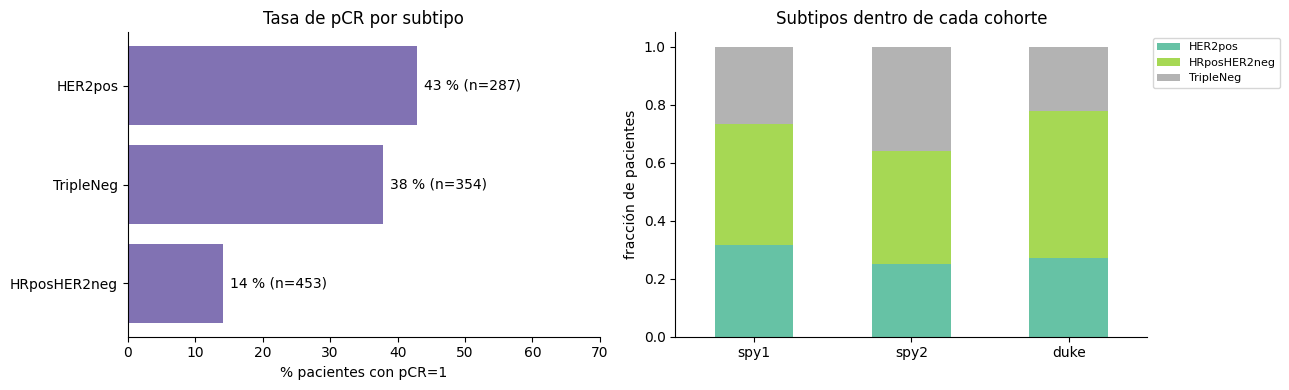

In [7]:
figura, ejes = plt.subplots(1, 2, figsize=(13, 4))
orden = subtipos.sort_values("tasa_pCR").index
ejes[0].barh(orden, subtipos.loc[orden, "tasa_pCR"], color="#8172B3")
for i, s in enumerate(orden):
    ejes[0].text(subtipos.loc[s, "tasa_pCR"] + 1, i, f"{subtipos.loc[s, 'tasa_pCR']:.0f} % (n={subtipos.loc[s, 'pacientes']})", va="center")
ejes[0].set(title="Tasa de pCR por subtipo", xlabel="% pacientes con pCR=1", xlim=(0, 70))

composicion = pd.crosstab(pac.dataset, pac.HR_HER2_STATUS, normalize="index").loc[COHORTES]
composicion.plot.bar(stacked=True, ax=ejes[1], colormap="Set2", rot=0)
ejes[1].set(title="Subtipos dentro de cada cohorte", ylabel="fracción de pacientes", xlabel="")
ejes[1].legend(fontsize=8, bbox_to_anchor=(1, 1))
figura.tight_layout()
guardar(figura, "subtipos")

## 4. Cómo se ven las imágenes

Una paciente pCR=0 y una pCR=1 de cada cohorte, en su corte central. Las columnas:
las tres fases, el **realce** (EARLY − PRE, dónde entra el contraste) y el **lavado**
(LATE − EARLY: rojo si sigue subiendo, azul si el contraste se va, que es el patrón
típico de tumor maligno).

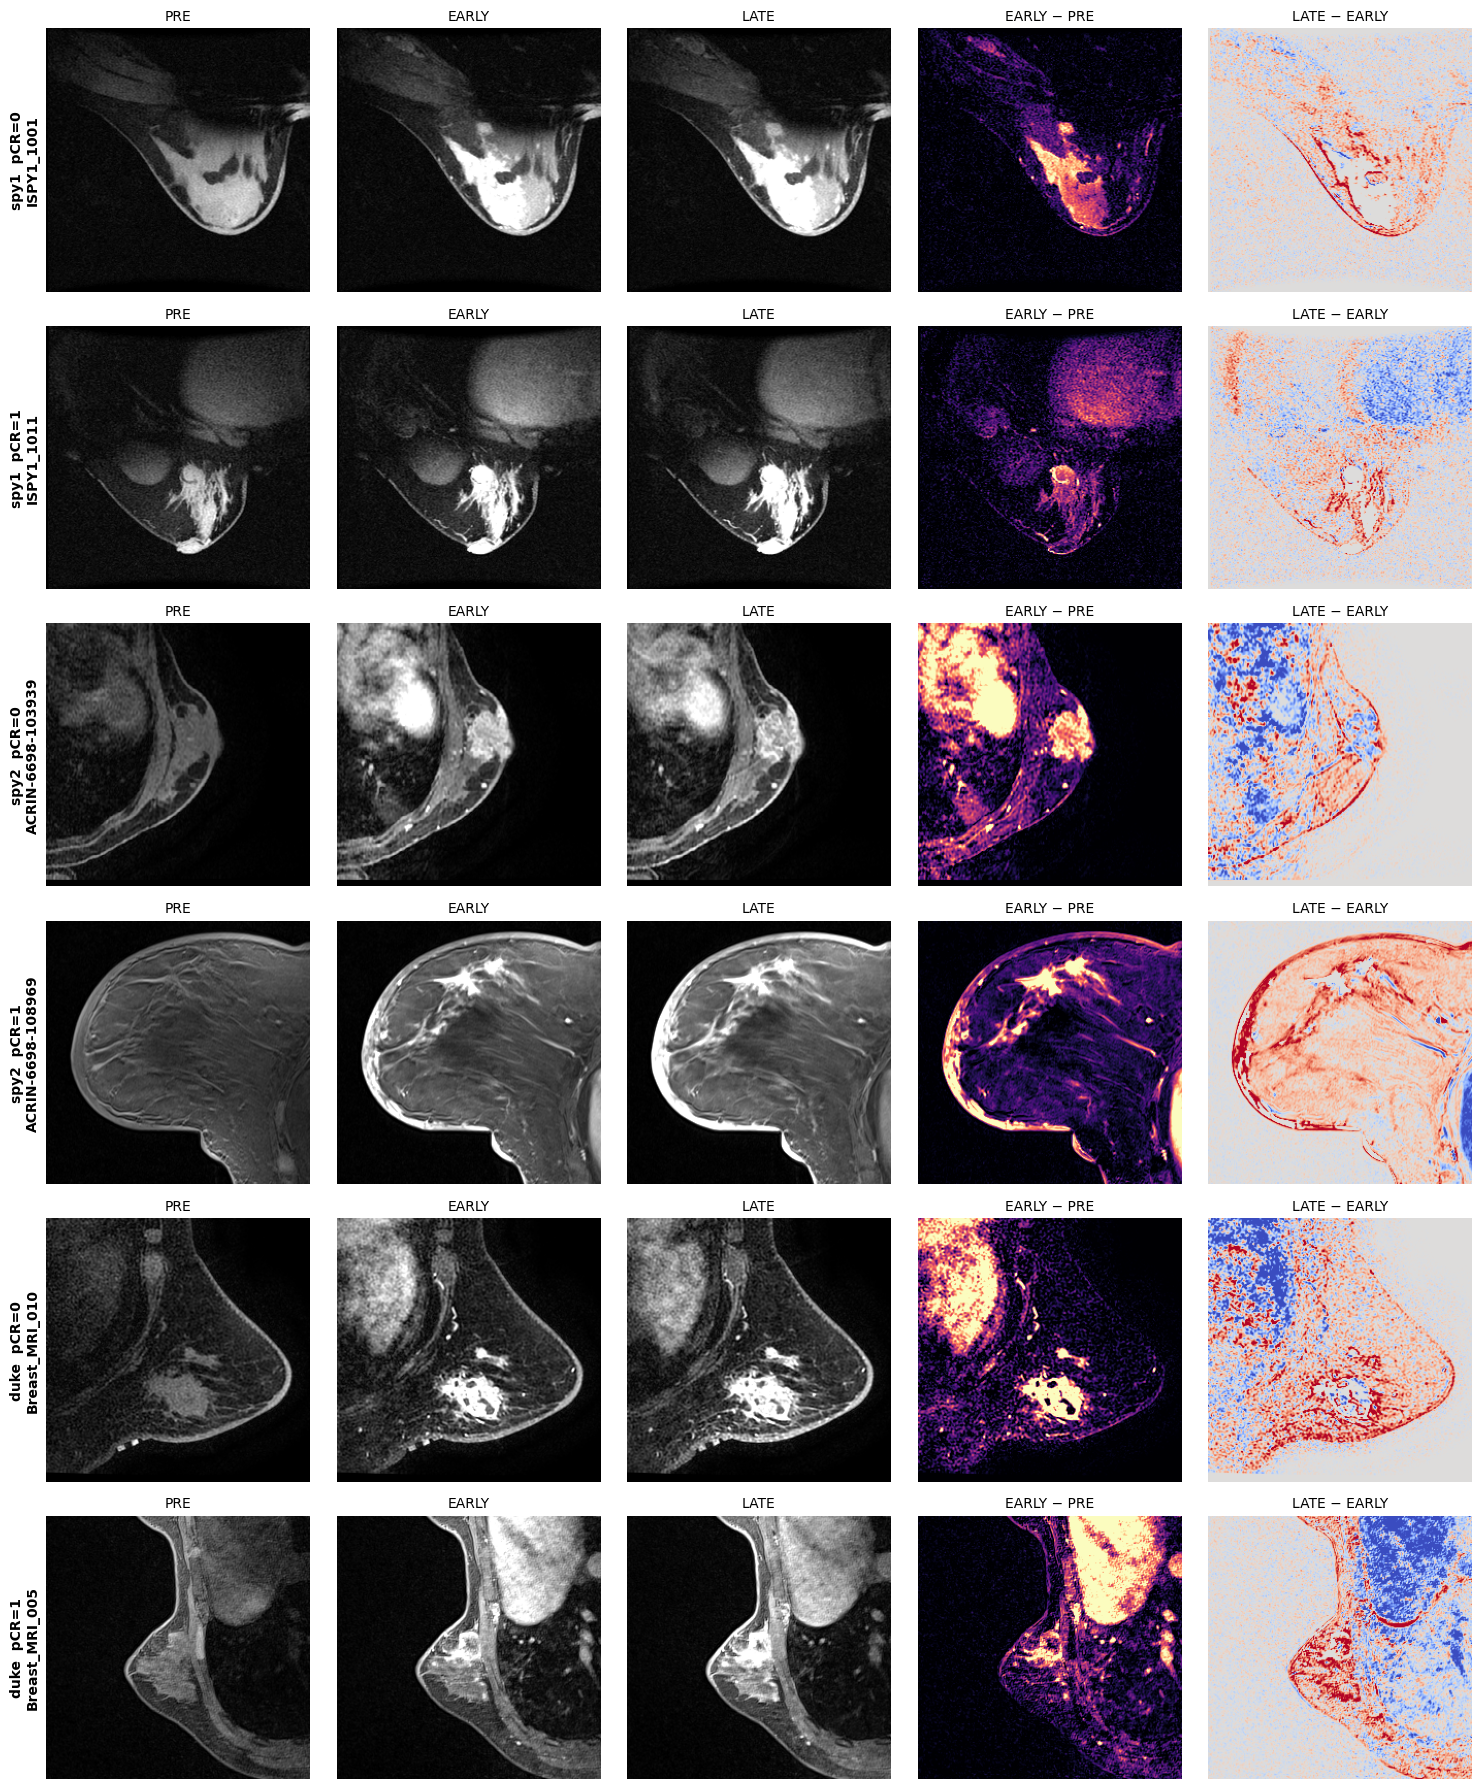

In [8]:
def corte_central(pid):
    cortes = train[train.patient_id == pid].sort_values("slice_index")
    return cortes.iloc[len(cortes) // 2]


figura, ejes = plt.subplots(6, 5, figsize=(15, 18))
fila_eje = 0
for c in COHORTES:
    for etiqueta in (0, 1):
        pid = sorted(pac.index[(pac.dataset == c) & (pac.pCR == etiqueta)])[0]
        fila = corte_central(pid)
        pre, early, late = uc.cargar_imagen(fila)
        paneles = [(pre, "PRE", "gray", 0, 1), (early, "EARLY", "gray", 0, 1), (late, "LATE", "gray", 0, 1),
                   (early - pre, "EARLY − PRE", "magma", 0, 0.5), (late - early, "LATE − EARLY", "coolwarm", -0.2, 0.2)]
        for eje, (plano, titulo, cmap, vmin, vmax) in zip(ejes[fila_eje], paneles):
            eje.imshow(plano, cmap=cmap, vmin=vmin, vmax=vmax)
            eje.set_title(titulo, fontsize=10)
            eje.axis("off")
        ejes[fila_eje, 0].text(-0.08, 0.5, f"{c}  pCR={etiqueta}\n{pid}", rotation=90, va="center", ha="center",
                               transform=ejes[fila_eje, 0].transAxes, fontsize=10, fontweight="bold")
        fila_eje += 1
figura.tight_layout()
guardar(figura, "ejemplos")

**Sobre las columnas `sraw`, `eraw`, `scol`, `ecol`.** La guía las describe como el
recorte del tumor. Al dibujar esa caja sobre la imagen de 256×256 no coincide con la
lesión, probablemente porque están en coordenadas del volumen original (`n_xy` va de
128 a 512 píxeles). No se usan para recortar sin verificarlo antes.

## 5. Intensidades por cohorte

Se carga el corte central de cada paciente de train y se resume su tejido (píxeles
con intensidad > 0,1 en alguna fase). Si las cohortes se distinguen con estadísticas
tan simples como la intensidad media o la cantidad de fondo, una CNN las distinguirá
sin esfuerzo, y como la tasa de pCR cambia entre cohortes (sección 2), puede usar eso
como atajo.

Tarda alrededor de un minuto en CPU.

In [9]:
# Los PNG son de 8 bits: intervalos de 4 niveles de gris, alineados con los 256
# posibles valores, para que el histograma no salga en dientes de sierra
BINS = (np.arange(0, 257, 4) - 0.5) / 255
BINS_REALCE = (np.arange(-76, 205, 4) - 0.5) / 255
histogramas = {c: {"PRE": np.zeros(len(BINS) - 1), "EARLY": np.zeros(len(BINS) - 1),
                   "realce": np.zeros(len(BINS_REALCE) - 1)} for c in COHORTES}
filas = []

for pid, cortes in train.sort_values("slice_index").groupby("patient_id"):
    fila = cortes.iloc[len(cortes) // 2]
    pre, early, late = x = uc.cargar_imagen(fila)
    realce, lavado = early - pre, late - early
    tejido = x.max(axis=0) > 0.1
    umbral = np.percentile(realce[tejido], 99)
    foco = tejido & (realce >= umbral)          # el 1 % de tejido que mas realza
    cohorte = pac.dataset[pid]
    filas.append({
        "pid": pid, "cohorte": cohorte, "pCR": fila.pCR, "fold": fila.fold,
        "fondo": 1 - tejido.mean(),
        "pre": pre[tejido].mean(), "early": early[tejido].mean(), "late": late[tejido].mean(),
        "realce_medio": realce[tejido].mean(),
        "realce_p99": umbral,
        # < 0: el contraste se va en la fase tardia (washout)
        "cinetica": lavado[foco].mean() / max(realce[foco].mean(), 1e-6),
    })
    histogramas[cohorte]["PRE"] += np.histogram(pre[tejido], BINS)[0]
    histogramas[cohorte]["EARLY"] += np.histogram(early[tejido], BINS)[0]
    histogramas[cohorte]["realce"] += np.histogram(realce[tejido], BINS_REALCE)[0]
    filas[-1]["saturado_early"] = (early[tejido] >= 1).mean()

img = pd.DataFrame(filas).set_index("pid")
img["washout"] = img.cinetica < -0.1
display(img.groupby("cohorte")[["fondo", "pre", "early", "late", "saturado_early", "realce_medio", "realce_p99", "washout"]]
           .mean().loc[COHORTES].round(3))

,fondo,pre,early,late,saturado_early,realce_medio,realce_p99,washout
cohorte,,,,,,,,
spy1,0.432,0.231,0.337,0.363,0.039,0.106,0.594,0.394
spy2,0.484,0.236,0.376,0.393,0.043,0.140,0.654,0.750
duke,0.481,0.214,0.331,0.355,0.030,0.117,0.663,0.780


Adivinar la cohorte con 6 estadisticas de intensidad: accuracy equilibrada 40.1% ± 1.3% (azar: 33,3 %)


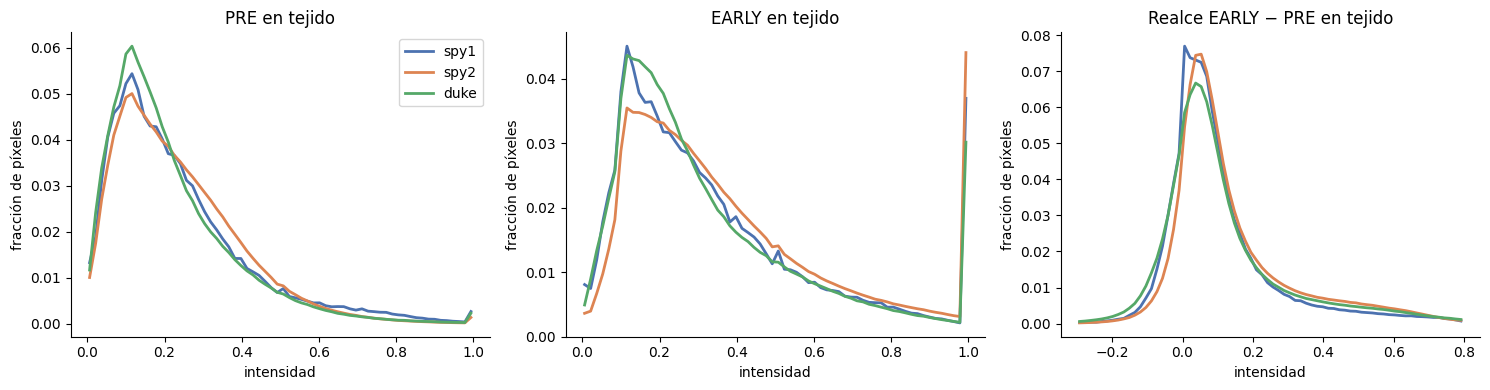

In [10]:
figura, ejes = plt.subplots(1, 3, figsize=(15, 4))
for eje, clave, bins, titulo in [(ejes[0], "PRE", BINS, "PRE en tejido"),
                                 (ejes[1], "EARLY", BINS, "EARLY en tejido"),
                                 (ejes[2], "realce", BINS_REALCE, "Realce EARLY − PRE en tejido")]:
    centros = (bins[:-1] + bins[1:]) / 2
    for c in COHORTES:
        h = histogramas[c][clave]
        eje.plot(centros, h / h.sum(), color=COLOR[c], label=c, lw=2)
    eje.set(title=titulo, xlabel="intensidad", ylabel="fracción de píxeles")
ejes[0].legend()
figura.tight_layout()
guardar(figura, "intensidades")

estadisticas = ["fondo", "pre", "early", "late", "realce_medio", "realce_p99"]
acierto = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
                          img[estadisticas], img.cohorte,
                          cv=StratifiedKFold(5, shuffle=True, random_state=0), scoring="balanced_accuracy")
print(f"Adivinar la cohorte con 6 estadisticas de intensidad: accuracy equilibrada "
      f"{acierto.mean():.1%} ± {acierto.std():.1%} (azar: 33,3 %)")

## 6. Realce y pCR

¿Separan las clases unas medidas simples del realce? Si ya hay algo de señal en un
único número por paciente, la CNN tiene de dónde aprender. Se mira dentro de cada
cohorte, porque una diferencia global podría ser solo la mezcla de cohortes.

`cinetica` compara lo que el foco de realce gana o pierde entre EARLY y LATE con lo
que ganó entre PRE y EARLY: por debajo de −0,1 es lavado (washout).

In [11]:
medidas = ["realce_medio", "realce_p99", "cinetica"]
aucs = {}
for grupo, datos in [("todas", img)] + [(c, img[img.cohorte == c]) for c in COHORTES]:
    aucs[grupo] = {m: roc_auc_score(datos.pCR, datos[m]) for m in medidas}
    aucs[grupo]["% washout pCR=0"] = 100 * datos.loc[datos.pCR == 0, "washout"].mean()
    aucs[grupo]["% washout pCR=1"] = 100 * datos.loc[datos.pCR == 1, "washout"].mean()
print("AUC de cada medida por si sola (0,5 = no separa; por debajo de 0,5 separa al reves):")
display(pd.DataFrame(aucs).T.round(3))

print("Regresion logistica con las medidas de imagen, 5 folds por paciente:")
print("  solo imagen:           ", auc_por_folds(img, estadisticas + ["cinetica"], []))
clinica_img = img.join(pac[["HR_HER2_STATUS", "age", "tum_vol"]])
print("  imagen + subtipo + edad:", auc_por_folds(clinica_img, estadisticas + ["cinetica", "age", "tum_vol"], ["HR_HER2_STATUS"]))

AUC de cada medida por si sola (0,5 = no separa; por debajo de 0,5 separa al reves):


,realce_medio,realce_p99,cinetica,% washout pCR=0,% washout pCR=1
todas,0.538,0.536,0.480,71.613,73.602
spy1,0.529,0.480,0.403,35.897,50.000
spy2,0.519,0.546,0.493,75.188,74.603
duke,0.546,0.523,0.473,76.970,81.818


Regresion logistica con las medidas de imagen, 5 folds por paciente:
  solo imagen:            0.515 ± 0.051
  imagen + subtipo + edad: 0.683 ± 0.031


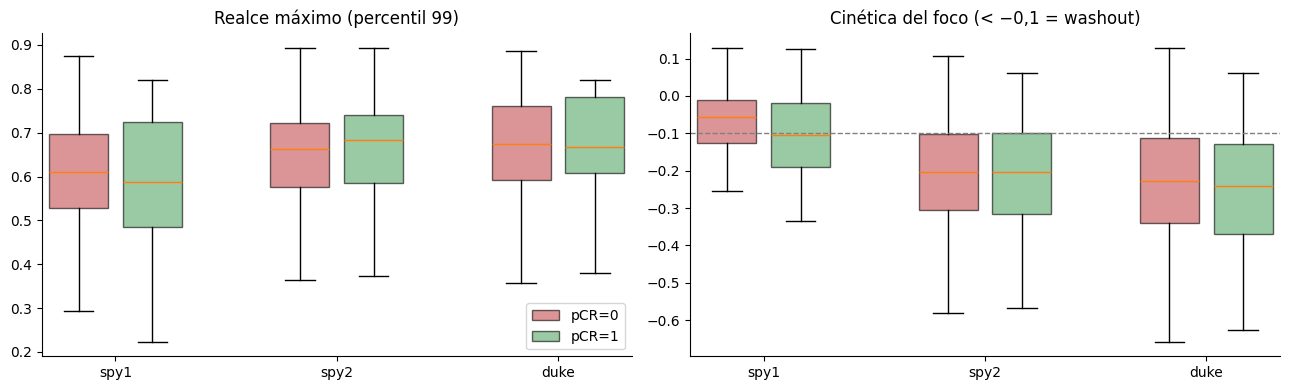

In [12]:
figura, ejes = plt.subplots(1, 2, figsize=(13, 4))
for eje, medida, titulo in [(ejes[0], "realce_p99", "Realce máximo (percentil 99)"),
                            (ejes[1], "cinetica", "Cinética del foco (< −0,1 = washout)")]:
    posiciones, datos, colores = [], [], []
    for i, c in enumerate(COHORTES):
        for etiqueta in (0, 1):
            posiciones.append(3 * i + etiqueta)
            datos.append(img.loc[(img.cohorte == c) & (img.pCR == etiqueta), medida])
            colores.append("#C44E52" if etiqueta == 0 else "#55A868")
    caja = eje.boxplot(datos, positions=posiciones, patch_artist=True, widths=0.8, showfliers=False)
    for parche, color in zip(caja["boxes"], colores):
        parche.set_facecolor(color)
        parche.set_alpha(0.6)
    eje.set_xticks([3 * i + 0.5 for i in range(3)], COHORTES)
    eje.set_title(titulo)
ejes[1].axhline(-0.1, color="gray", ls="--", lw=1)
ejes[0].legend([caja["boxes"][0], caja["boxes"][1]], ["pCR=0", "pCR=1"])
figura.tight_layout()
guardar(figura, "realce_pcr")

## 7. Los cortes de una paciente

Dos preguntas de diseño:

- **¿Son contiguos?** Si los ~10 cortes son alturas seguidas, una red 3D o que mire
  varios cortes a la vez tendría sentido. Si están salteados, no.
- **¿Cuánto se parecen?** Si los cortes de una paciente son casi iguales, 10.945
  cortes equivalen a mucho menos que 10.945 ejemplos independientes, y el riesgo de
  sobreajuste es el de ~1.100 pacientes.

El parecido se mide con la correlación entre mapas de realce reducidos a 64×64, en
150 pacientes al azar.

In [13]:
saltos = train.sort_values("slice_index").groupby("patient_id").slice_index.apply(lambda z: np.diff(z.values))
todos = np.concatenate(saltos.values)
contiguas = saltos.apply(lambda d: bool((d == 1).all()))
print(f"Saltos entre cortes consecutivos: {pd.Series(todos).value_counts().sort_index().head(8).to_dict()}")
print(f"Pacientes con todos sus cortes contiguos: {contiguas.mean():.1%}")
display(contiguas.groupby(pac.dataset).mean().loc[COHORTES].rename("% contiguas").mul(100).round(1).to_frame())

Saltos entre cortes consecutivos: {1: 9489, 2: 138, 3: 60, 4: 47, 5: 35, 6: 23, 7: 14, 8: 7}
Pacientes con todos sus cortes contiguos: 75.2%


,% contiguas
dataset,
spy1,70.2
spy2,69.3
duke,100.0


Correlacion media entre cortes vecinos de la misma paciente: 0.94
Correlacion media entre cortes cualesquiera de la misma paciente: 0.81
Correlacion media entre pacientes distintas: 0.08


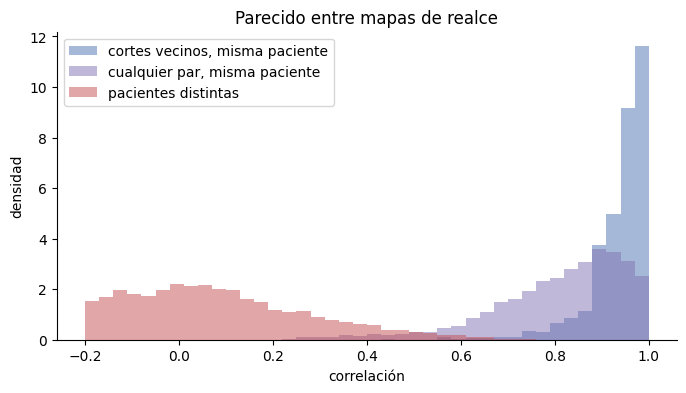

In [14]:
def mapa_realce(fila):
    pre, early, _ = uc.cargar_imagen(fila)
    return (early - pre).reshape(64, 4, 64, 4).mean(axis=(1, 3)).ravel()


rng = np.random.default_rng(0)
muestra = rng.choice(pac.index, size=150, replace=False)
dentro, vecinos, centrales = [], [], []
for pid in muestra:
    cortes = train[train.patient_id == pid].sort_values("slice_index")
    mapas = np.array([mapa_realce(f) for f in cortes.itertuples()])
    r = np.corrcoef(mapas)
    dentro.extend(r[np.triu_indices(len(r), 1)])
    vecinos.extend(np.diag(r, 1))
    centrales.append(mapas[len(mapas) // 2])
r = np.corrcoef(np.array(centrales))
entre = r[np.triu_indices(len(r), 1)]

print(f"Correlacion media entre cortes vecinos de la misma paciente: {np.mean(vecinos):.2f}")
print(f"Correlacion media entre cortes cualesquiera de la misma paciente: {np.mean(dentro):.2f}")
print(f"Correlacion media entre pacientes distintas: {np.mean(entre):.2f}")

figura, eje = plt.subplots(figsize=(8, 4))
for valores, etiqueta, color in [(vecinos, "cortes vecinos, misma paciente", "#4C72B0"),
                                 (dentro, "cualquier par, misma paciente", "#8172B3"),
                                 (entre, "pacientes distintas", "#C44E52")]:
    eje.hist(valores, bins=40, range=(-0.2, 1), density=True, alpha=0.5, color=color, label=etiqueta)
eje.set(title="Parecido entre mapas de realce", xlabel="correlación", ylabel="densidad")
eje.legend()
guardar(figura, "cortes")

## Conclusiones

Todo sobre las 1.097 pacientes de `train`. Las cifras son las de las celdas de arriba.

### Lo que hemos visto

1. **Desbalance de 70,6 / 29,4, igual por paciente que por corte.** 1.091 de las 1.097
   pacientes tienen exactamente 10 cortes, así que ninguna clase aporta más cortes que la
   otra. `pos_weight` = 2,40.
2. **Las cohortes tienen tasas de pCR distintas** (spy1 25 %, spy2 32 %, duke 21 %;
   chi-cuadrado p = 0,004), pero saber solo la cohorte predice poco: AUC 0,55. También
   se adquirieron de forma distinta: 3, 7 y 4 instantes de contraste de mediana, y los
   tumores de duke son más pequeños (mediana de 6 frente a 14-15).
3. **El subtipo tumoral predice bastante sin imagen.** HER2+ 43 %, triple negativo 38 %,
   HR+/HER2− 14 % de pCR. Una regresión logística con subtipo, edad y volumen llega a
   **AUC 0,69** en los mismos 5 folds. Es la referencia que la CNN tiene que superar.
4. **Las imágenes son la mama entera, no un recorte del tumor.** El tumor ocupa una
   parte pequeña del corte, y el corazón y otros órganos realzan tanto o más que él.
   La orientación cambia entre cohortes y dentro de la misma cohorte. Las columnas
   `sraw`/`eraw`/`scol`/`ecol` no coinciden con el tumor en la imagen de 256×256.
5. **Las intensidades se parecen entre cohortes.** Con 6 estadísticas de intensidad la
   cohorte solo se adivina en un 40 % (azar: 33 %). Entre un 3 % y un 4 % del tejido
   está saturado (valor 1,0) en EARLY: el realce más fuerte se recorta.
6. **Una medida global del realce no separa pCR** (AUC entre 0,48 y 0,55; la
   combinación de medidas, 0,52). Si hay señal en la imagen, está en la forma o la
   textura local del tumor, no en un número por corte.
7. **LATE − EARLY no significa lo mismo en todas las cohortes.** El lavado aparece en el
   39 % de spy1 frente al 75-78 % de spy2 y duke. Encaja con que "LATE" es el
   instante 2 en spy1, el 5 en spy2 y el 3 en duke: el tiempo real entre fases cambia.
8. **Los cortes de una paciente son casi el mismo dato.** Correlación de 0,94 entre
   cortes vecinos y de 0,81 entre cualquier par, frente a 0,08 entre pacientes. Solo el
   75 % de las pacientes tiene todos sus cortes contiguos (duke el 100 %, spy1 y spy2
   alrededor del 70 %).

### Qué implica para el modelo (provisional)

- **El tamaño de muestra efectivo es de ~1.100 pacientes, no de 10.945 cortes.** La red
  tiene que ser pequeña y regularizada, y el aumentado de datos es importante.
- **Volteos y rotaciones están justificados**: la orientación ya varía en los datos.
- **No se puede recortar el tumor con las columnas del CSV.** La red ve el corte entero
  y tiene que aprender a ignorar el corazón. Recortar exigiría otra forma de localizar
  el tumor.
- **Los canales de realce son una hipótesis a probar, no una decisión.** Las medidas
  globales no separan las clases. Se comparará la red con y sin ellos (ablación).
- **LATE − EARLY puede meter sesgo de cohorte**, porque su significado depende del
  protocolo. Conviene probar también la red sin la fase LATE.
- **Referencias para interpretar la CNN:** predecir siempre pCR=0 da 70,6 % de
  accuracy; solo la cohorte, AUC 0,55; variables clínicas, AUC 0,69. Las métricas se
  darán también por cohorte.
- **Una red 3D no está justificada**: una de cada cuatro pacientes tiene saltos entre
  cortes, y los cortes vecinos aportan poca información nueva.
- **Pregunta para el profesor:** ¿se pueden combinar las variables clínicas con la
  imagen? El subtipo ya da AUC 0,66 por sí solo.

### Limitaciones de este EDA

- Las medidas de intensidad y realce usan solo el corte central de cada paciente.
- El "foco de realce" es el 1 % de tejido que más realza, y a veces cae en el corazón
  en lugar del tumor, lo que diluye la medida de cinética.
- El parecido entre cortes se midió en 150 pacientes al azar, no en todas.